In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [3]:
wid = 64
oversample = 4

nwavels = 20#13#6
npoly=4

n_zernikes = 30

optics = NICMOSFresnelOptics(512, wid, oversample, n_zernikes = n_zernikes, defocus=0., fnumber=80.)

detector = NICMOSDetector(oversample, wid)

ddir = "../data/MAST_2024-09-22T03_37_01.724Z/HST/"


# data = np.load("spectrum_iterative.npz", allow_pickle=True)
# weights = data["weights"]
# params = data["params"][()]

# weights_downsampled = ipx.interp1d(np.linspace(0,1,nwavels), np.linspace(0,1,weights.shape[0]), weights)

vects = np.load("../data/iterative_spectrum_basis_F160W.npy")[:,:npoly]

assert vects.shape == (nwavels, npoly)


spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))



ddir = "../data/MAST_2024-09-26T22_53_13.719Z/HST/"

exposures_single = [
    exposure_from_file(ddir + "n8ry03vbq_cal.fits", SinglePointFit(spectrum_basis, "F160W"), crop=wid),
    exposure_from_file(ddir + "n8ry03vcq_cal.fits", SinglePointFit(spectrum_basis, "F160W"), crop=wid),
    exposure_from_file(ddir + "n8ry04vfq_cal.fits", SinglePointFit(spectrum_basis, "F160W"), crop=wid),
    exposure_from_file(ddir + "n8ry04vgq_cal.fits", SinglePointFit(spectrum_basis, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry05vmq_cal.fits", SinglePointFit(spectrum_basis, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry05vnq_cal.fits", SinglePointFit(spectrum_basis, "F160W"), crop=wid),
    ##exposure_from_file(ddir + "n8ry06vpq_cal.fits", SinglePointFit(spectrum_basis, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry06vqq_cal.fits", SinglePointFit(spectrum_basis, "F160W"), crop=wid),

]


W0721 16:34:02.721720 24316386 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Version 4.4.1
207 60
Version 4.4.1
207 187
Version 4.4.1
206 51
Version 4.4.1
207 178


/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This

In [4]:
for e in exposures_single:
    print(e.mjd)#*86400)
    print(e.target)
    print(e.filter)
    print(e.exptime)

52947.56708054
HZ4
F160W
319.9581
52947.57138609
HZ4
F160W
319.9581
52947.58649019
HZ4
F160W
319.9581
52947.59079576
HZ4
F160W
319.9581


In [5]:
params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},

    #"rot": 0.,

    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,

    "softening": 20.,#0.1,
    "bias": {},
    "jitter": {},

    "defocus": {},#1e5#{}
    "fnumber": 79.68,
    "quadrature": {},
}



for idx, exp in enumerate(exposures_single):
    params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels))/0.3
    params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)
    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([6.,6.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.
    

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample
    params["quadrature"][exp.fit.get_key(exp, "quadrature")] = 0.


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))
#model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params = ModelParams(params)

17.19457957394203
8.626105649404002
5.151802125055777
17.223293470448834


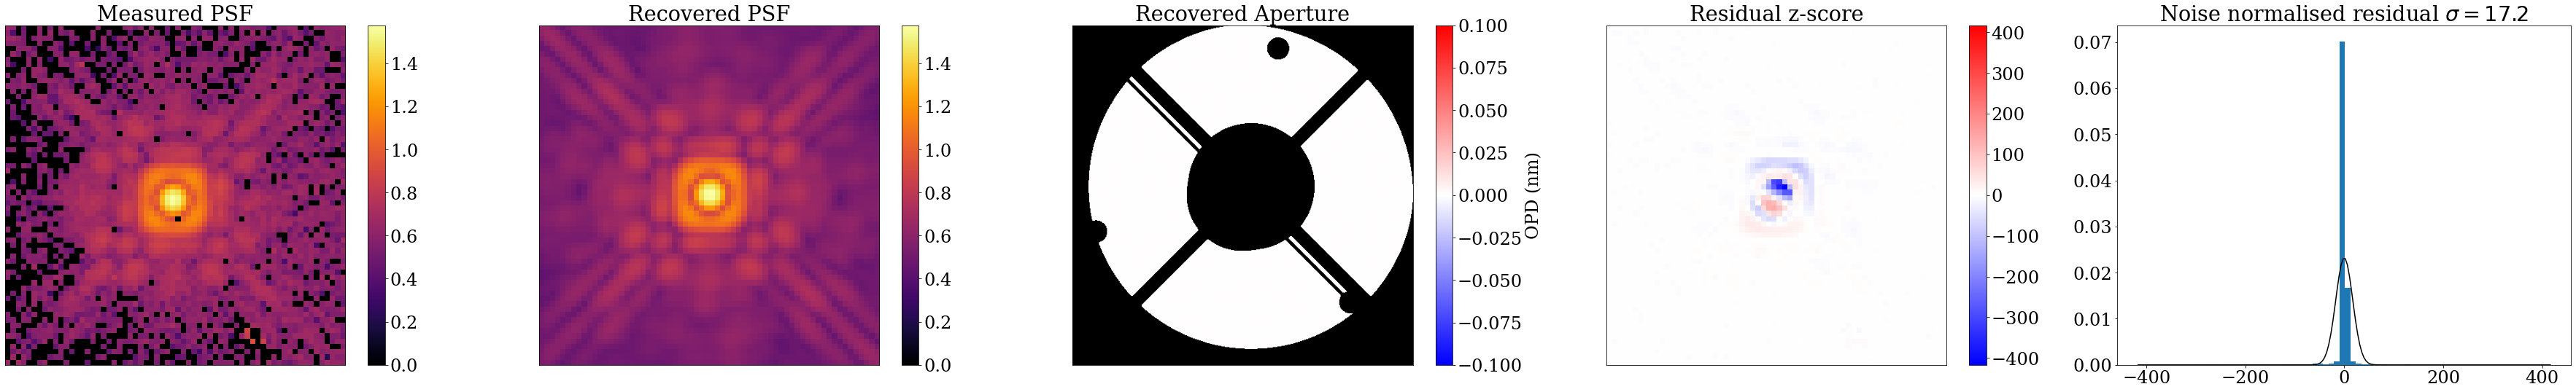

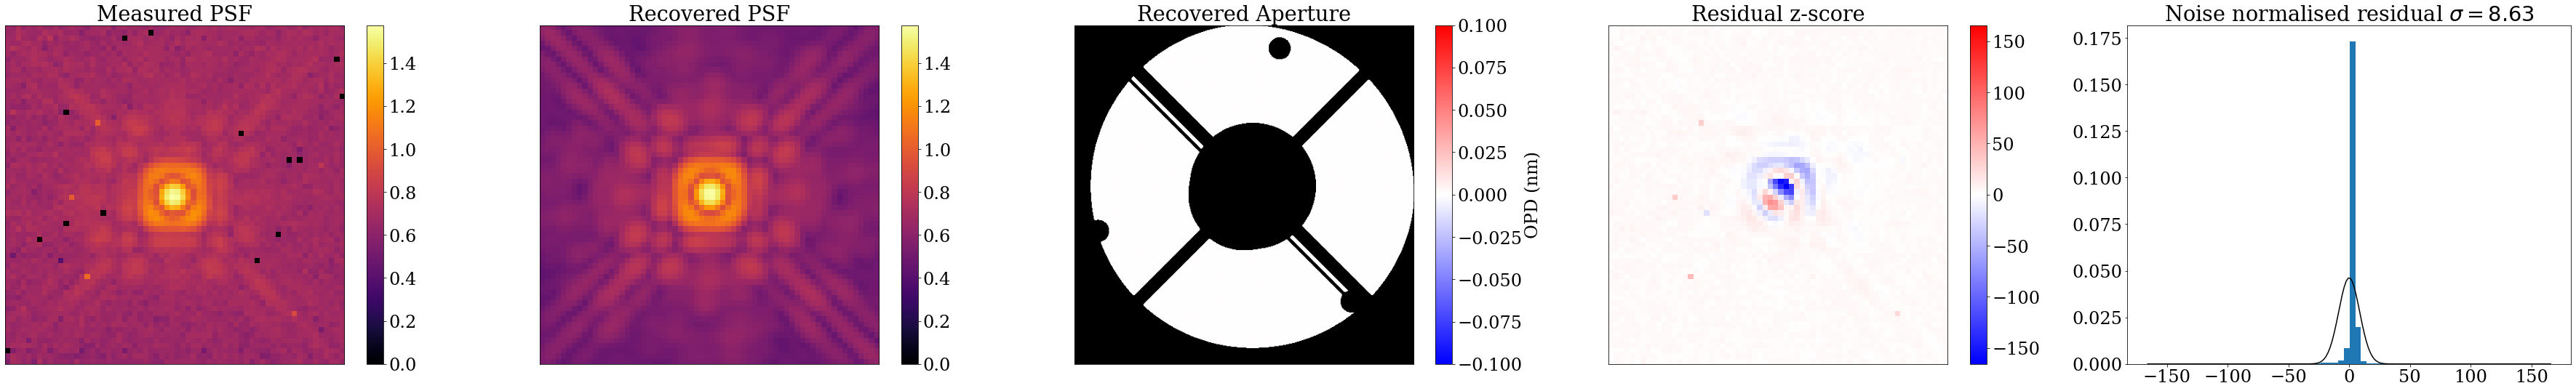

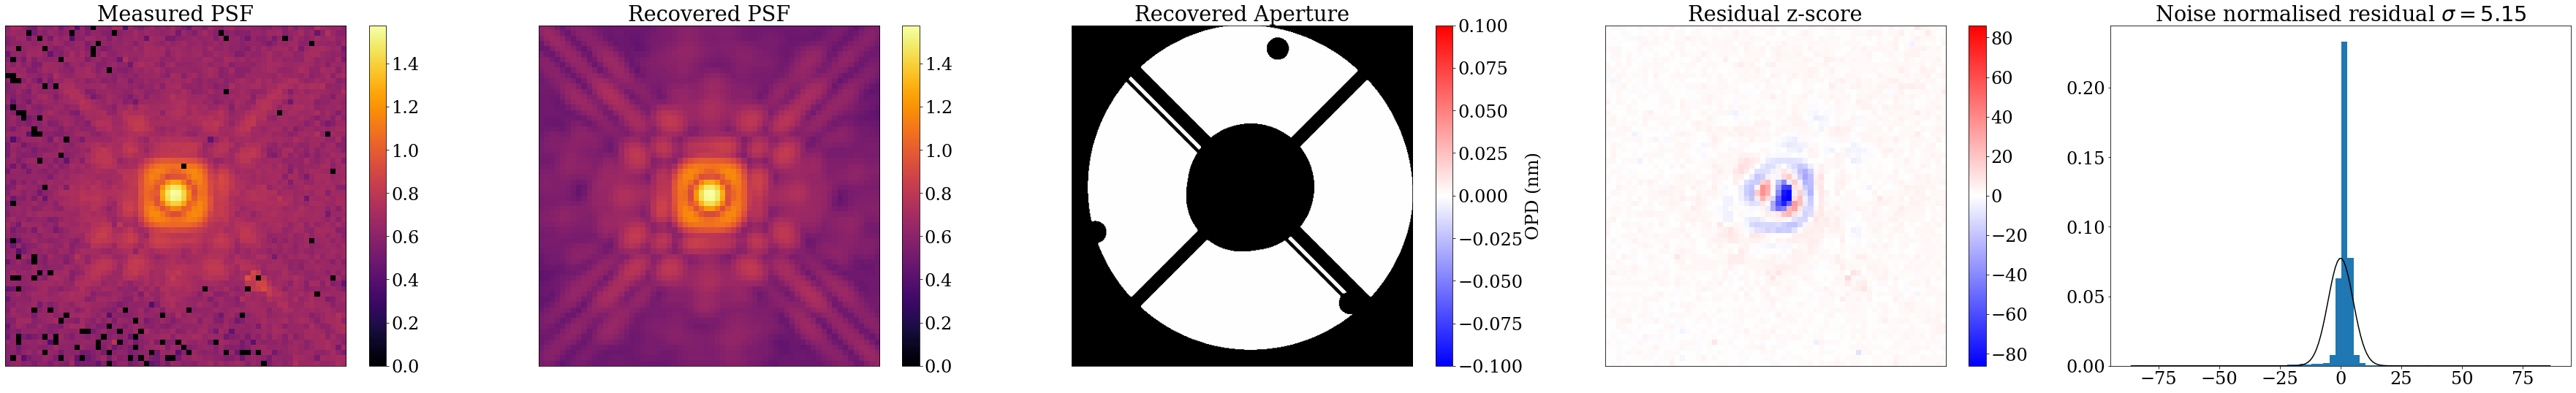

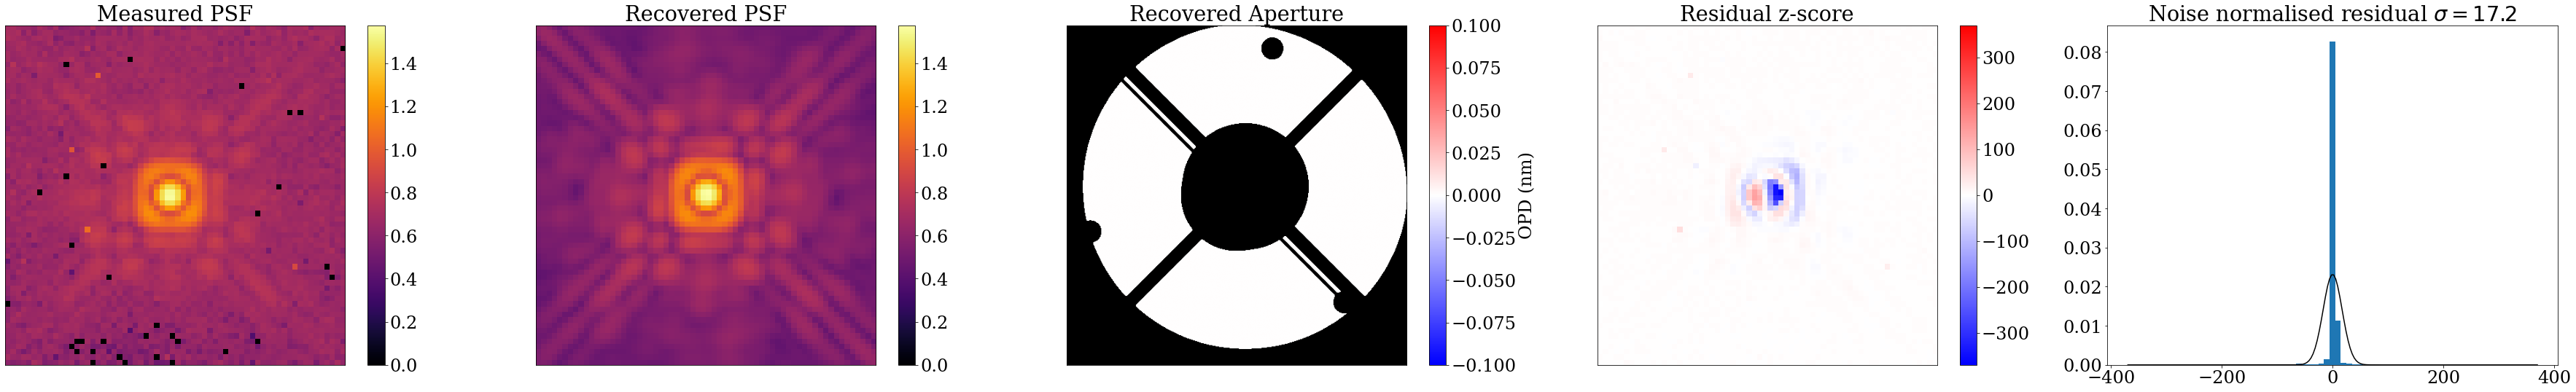

In [6]:
plot_comparison(model_single, params, exposures_single)

In [7]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

g = 5e-2

things = {
    "positions": sgd(g*2.5, 0),
    "spectrum": sgd(g*0.3, 10),
    "bias": sgd(g*3, 20),
    "cold_mask_shift": sgd(g*0.3, 30),
    "defocus": sgd(g*2, 30),
    "aberrations": sgd(g*0.08, 70),

    
    # #"fnumber": sgd(g*3, 100),
    # "cold_mask_shear": sgd(g*0.5, 100),

    "quadrature": sgd(g*25, 550),
}

things_start = {
    "positions": sgd(g*5, 0),
    "spectrum": sgd(g*0.2, 10),
}

groups = list(things.keys())

In [8]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [9]:
opt_params

{'positions': {'n8ry03vbq': Array([0., 0.], dtype=float64),
  'n8ry03vcq': Array([0., 0.], dtype=float64),
  'n8ry04vfq': Array([0., 0.], dtype=float64),
  'n8ry04vgq': Array([0., 0.], dtype=float64)},
 'spectrum': {'HZ4_F160W': Array([136.9361003,   0.       ,   0.       ,   0.       ], dtype=float64)}}

In [10]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 20)

  0%|          | 0/20 [00:00<?, ?it/s]

3.0223811803065663
3.513094382995992
3.1434920541499256
3.479147577105112


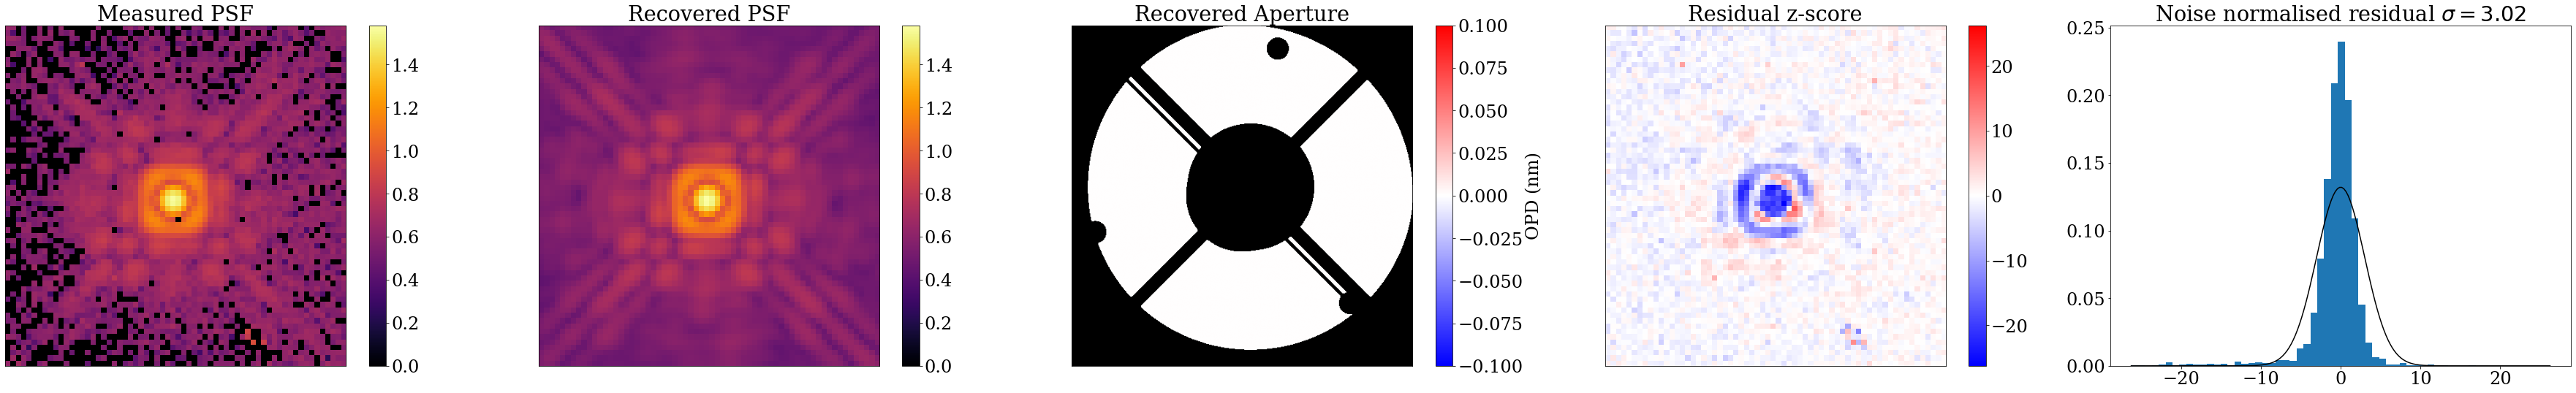

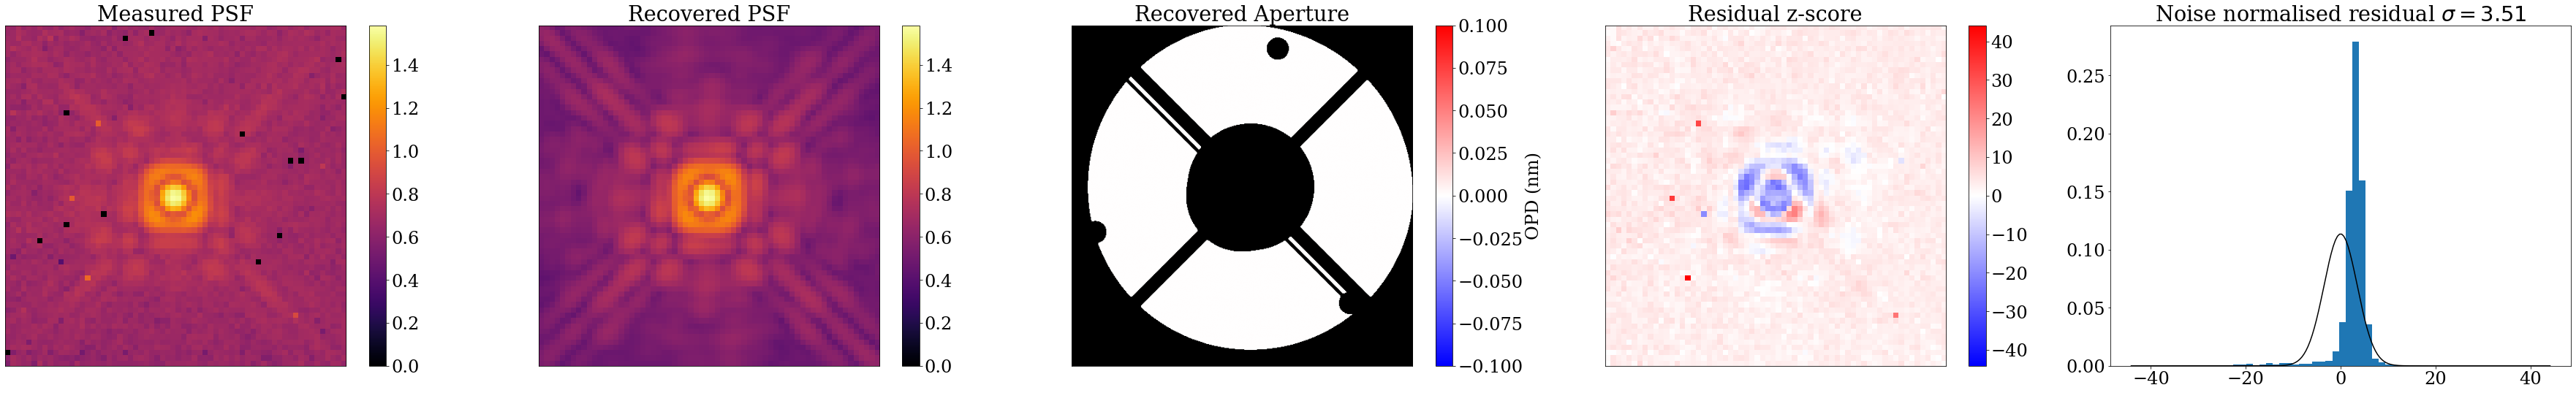

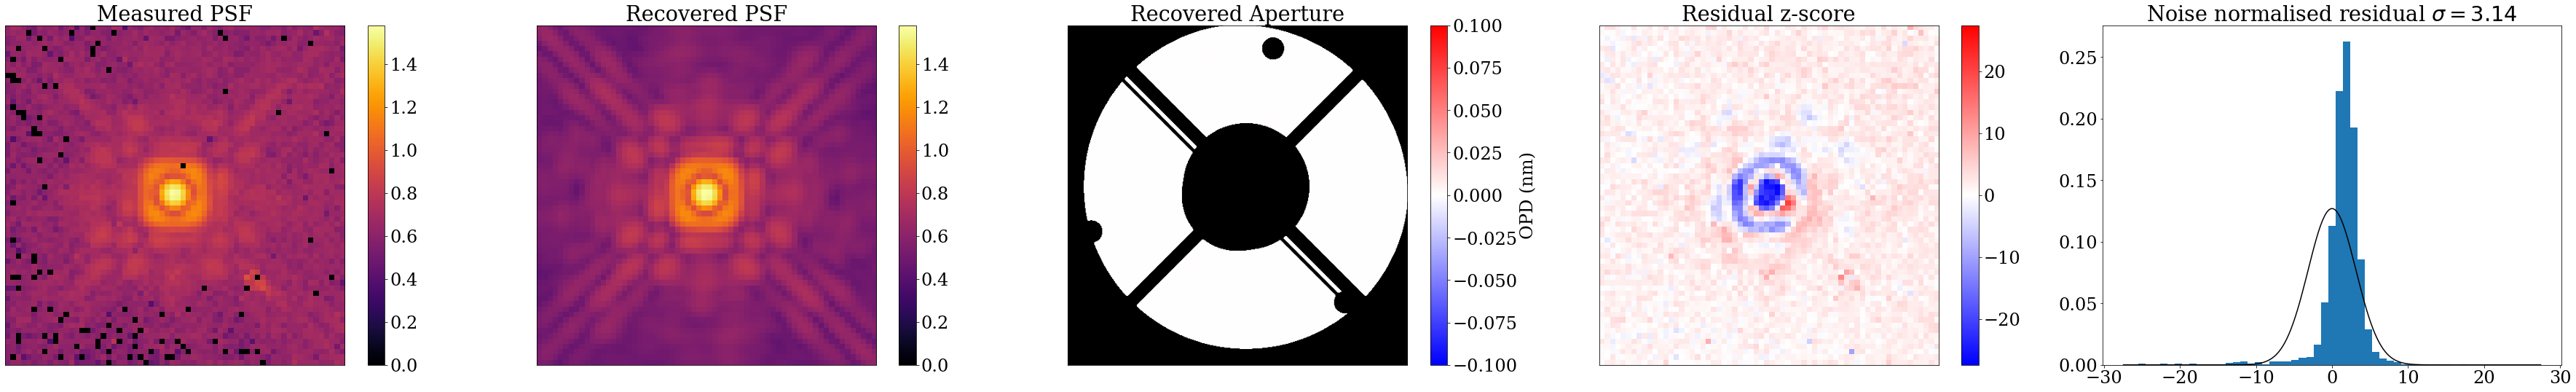

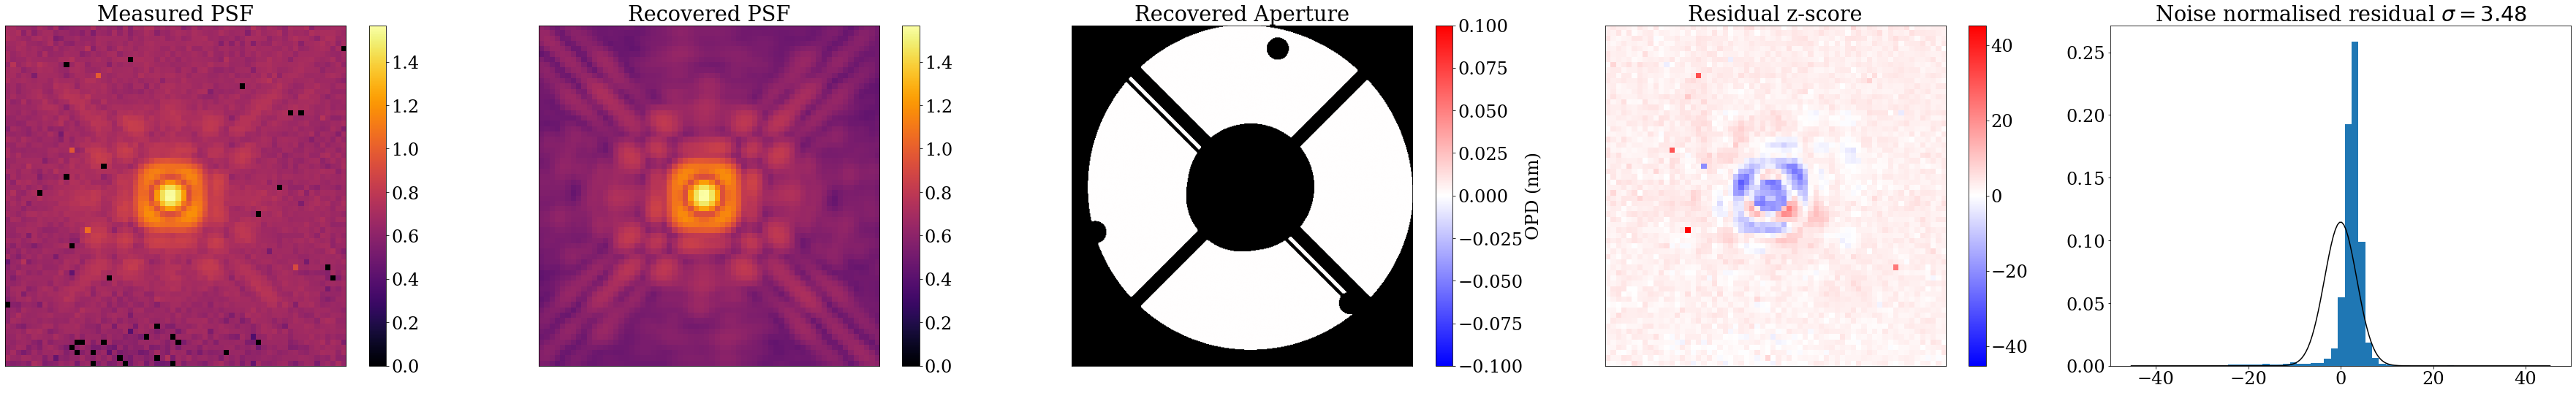

In [11]:
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

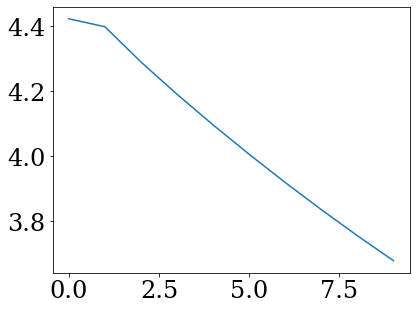

In [12]:
plt.plot(np.asarray(losses[-10:])/(len(exposures_single)*wid**2))

In [13]:
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [14]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things, 600, nbatches=40)

  0%|          | 0/600 [00:00<?, ?it/s]

In [15]:
len(losses)

600

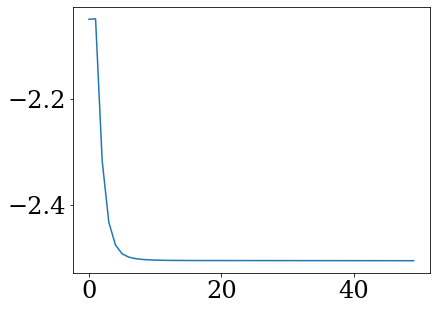

In [16]:
plt.plot(np.asarray(losses[-50:])/(len(exposures_single)*wid**2))

In [17]:
params_history_relative = [jax.tree.map(lambda x, y: x-y, x, params_history[0]) for x in params_history]

7
0.9985371906004595
0.9989261043119042
0.9977044495945849
0.998621924015701


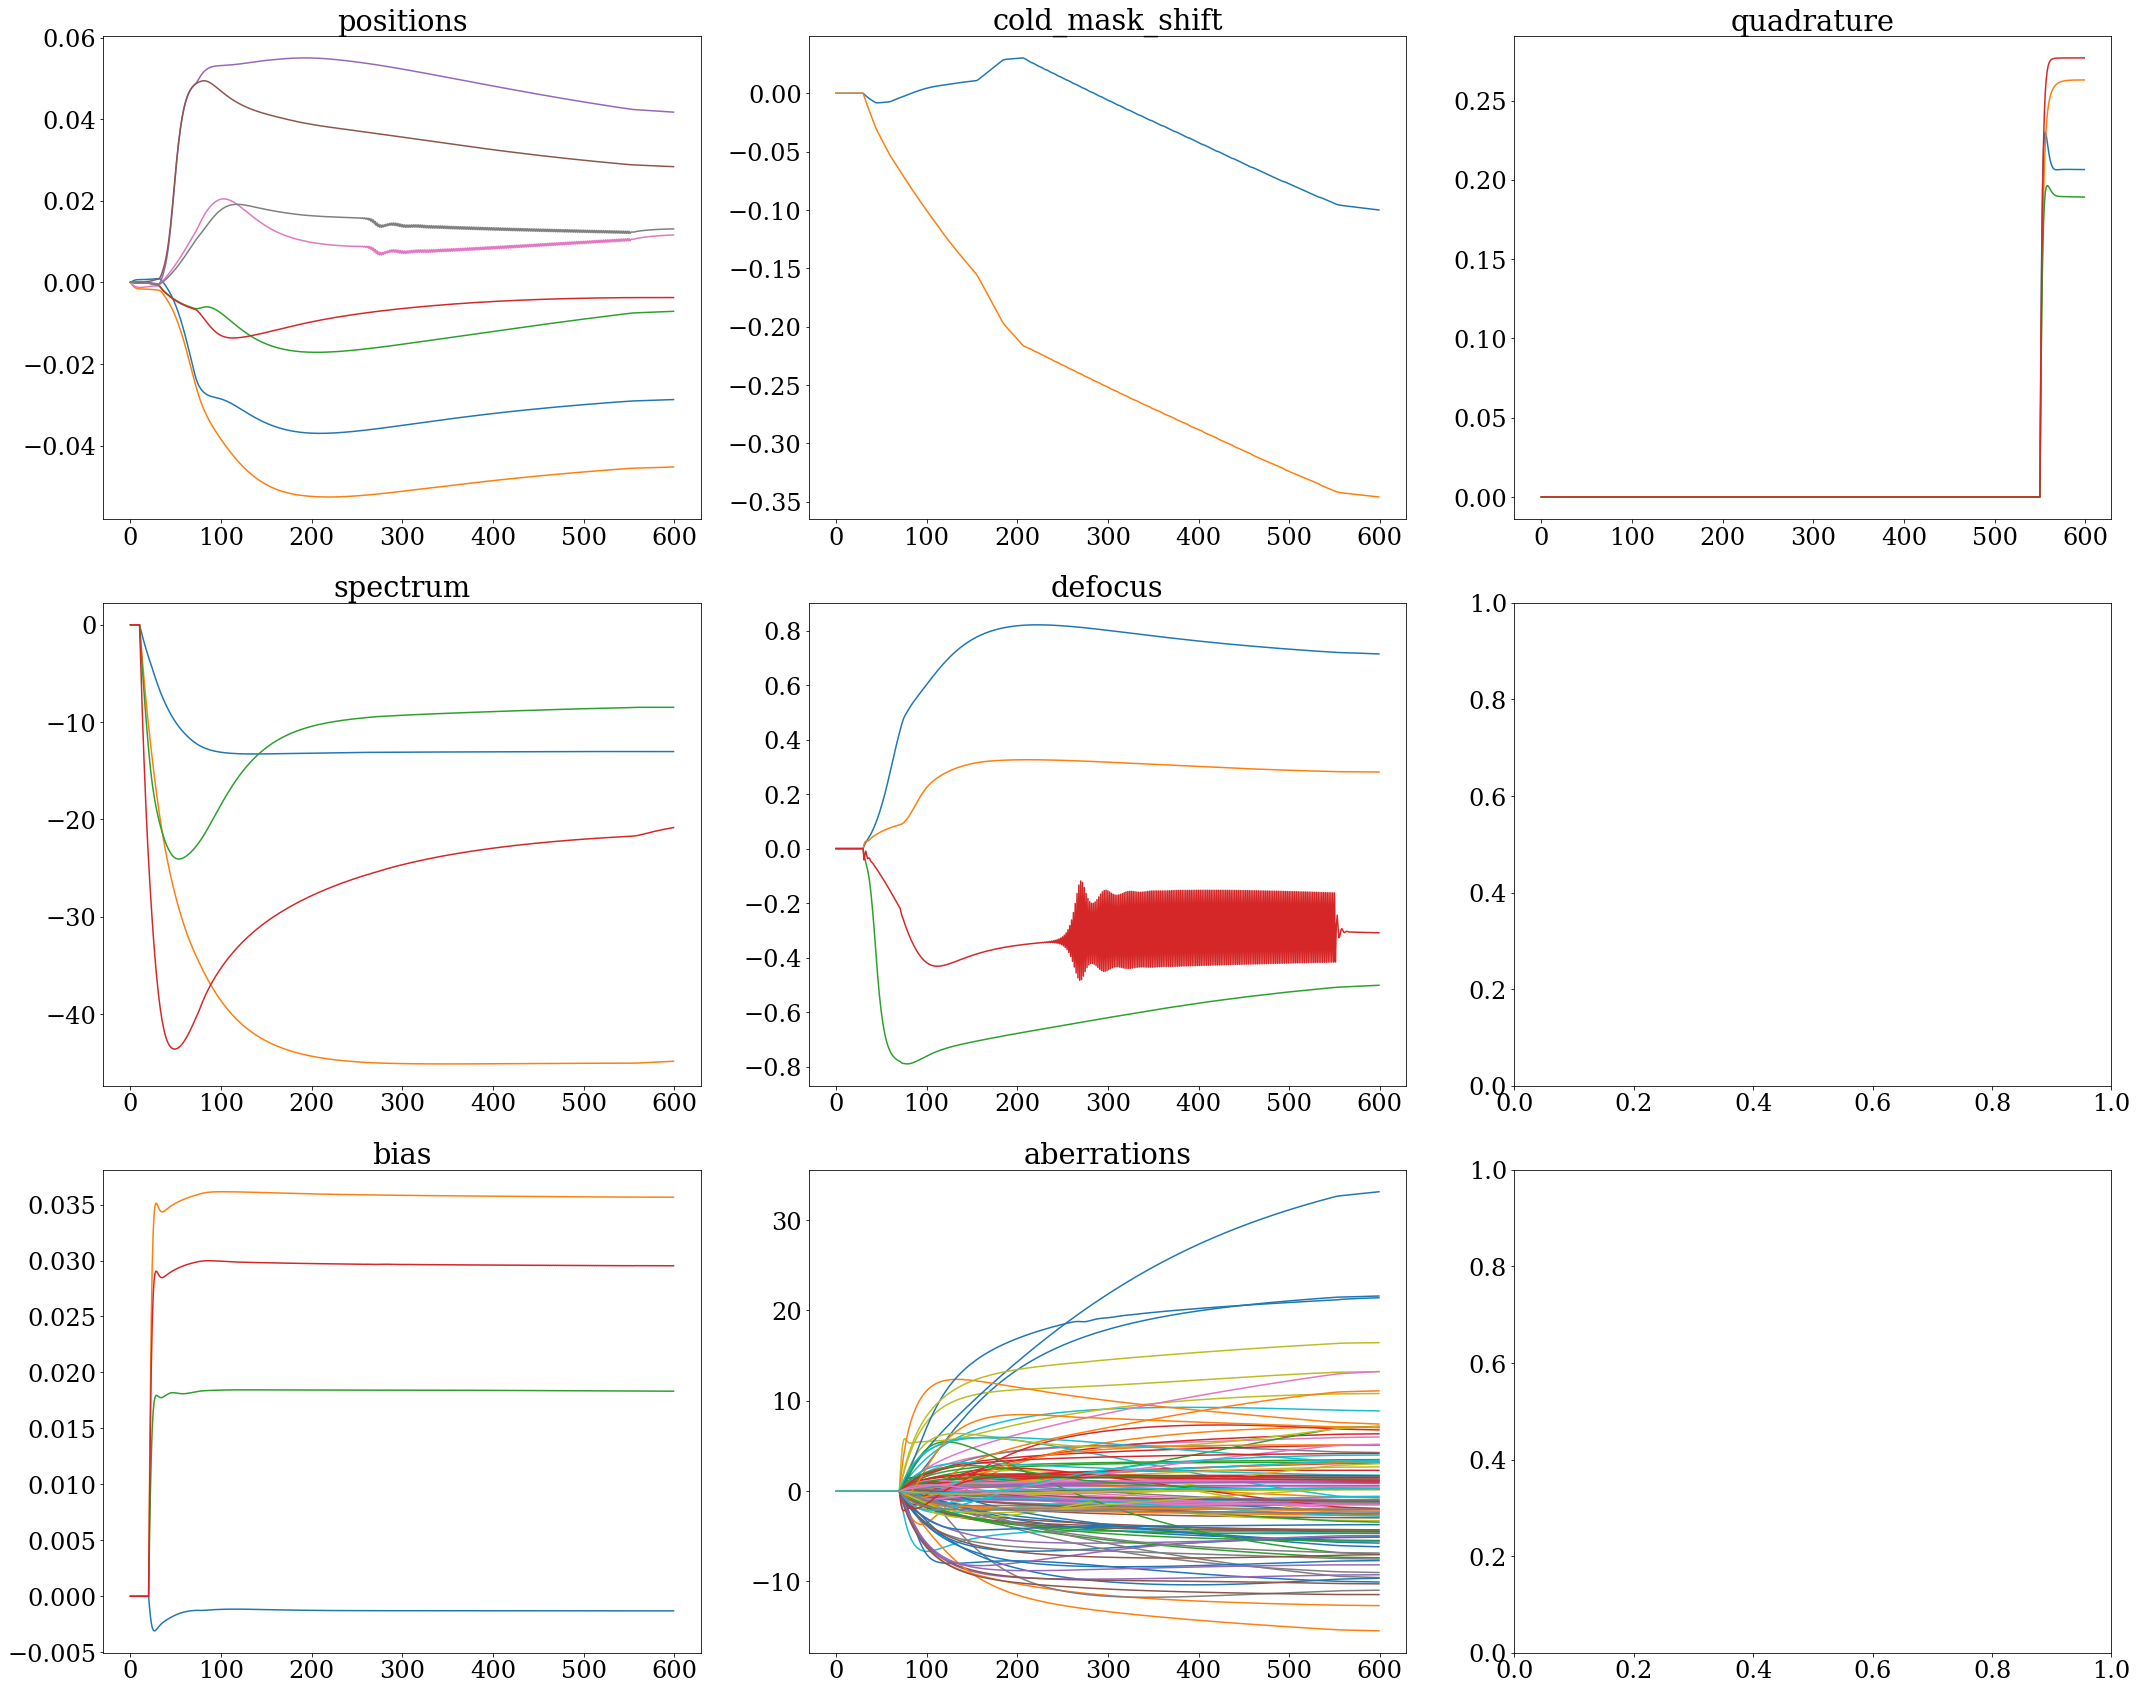

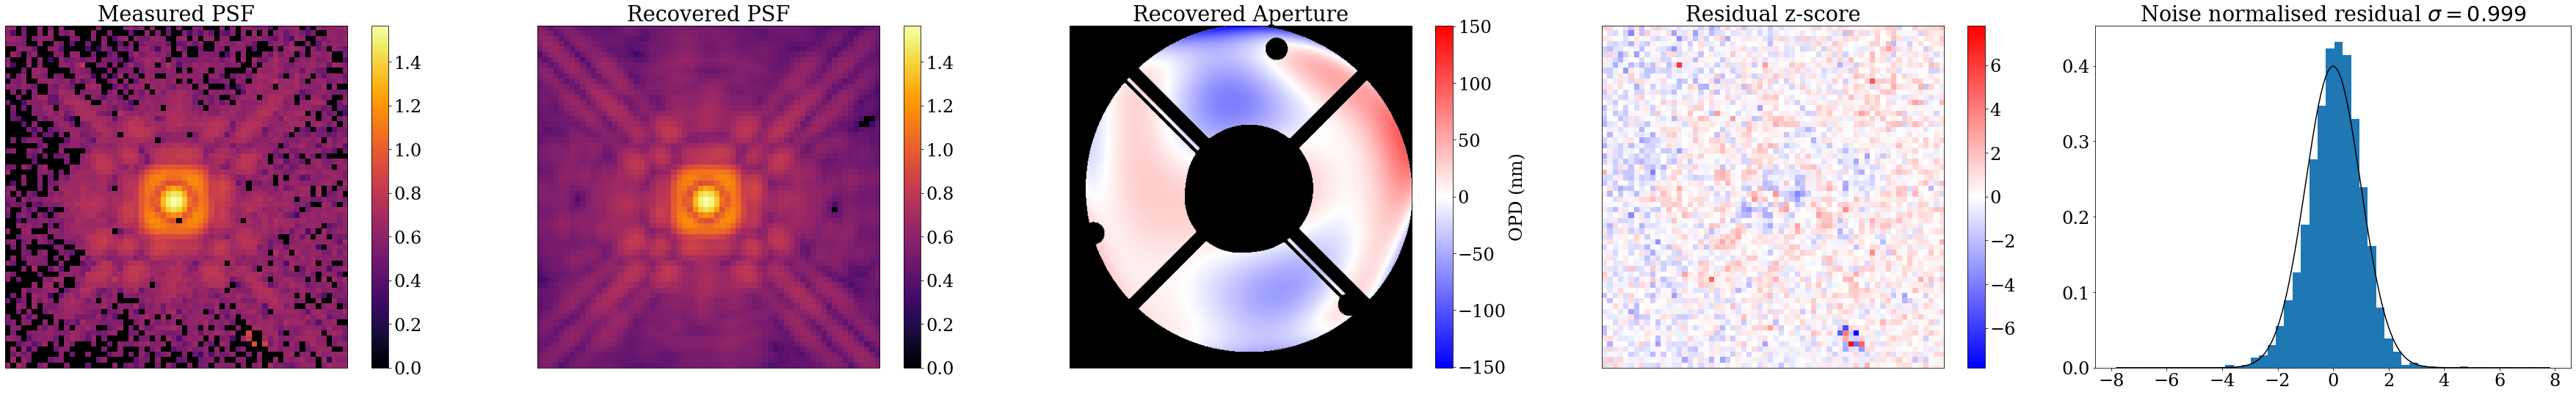

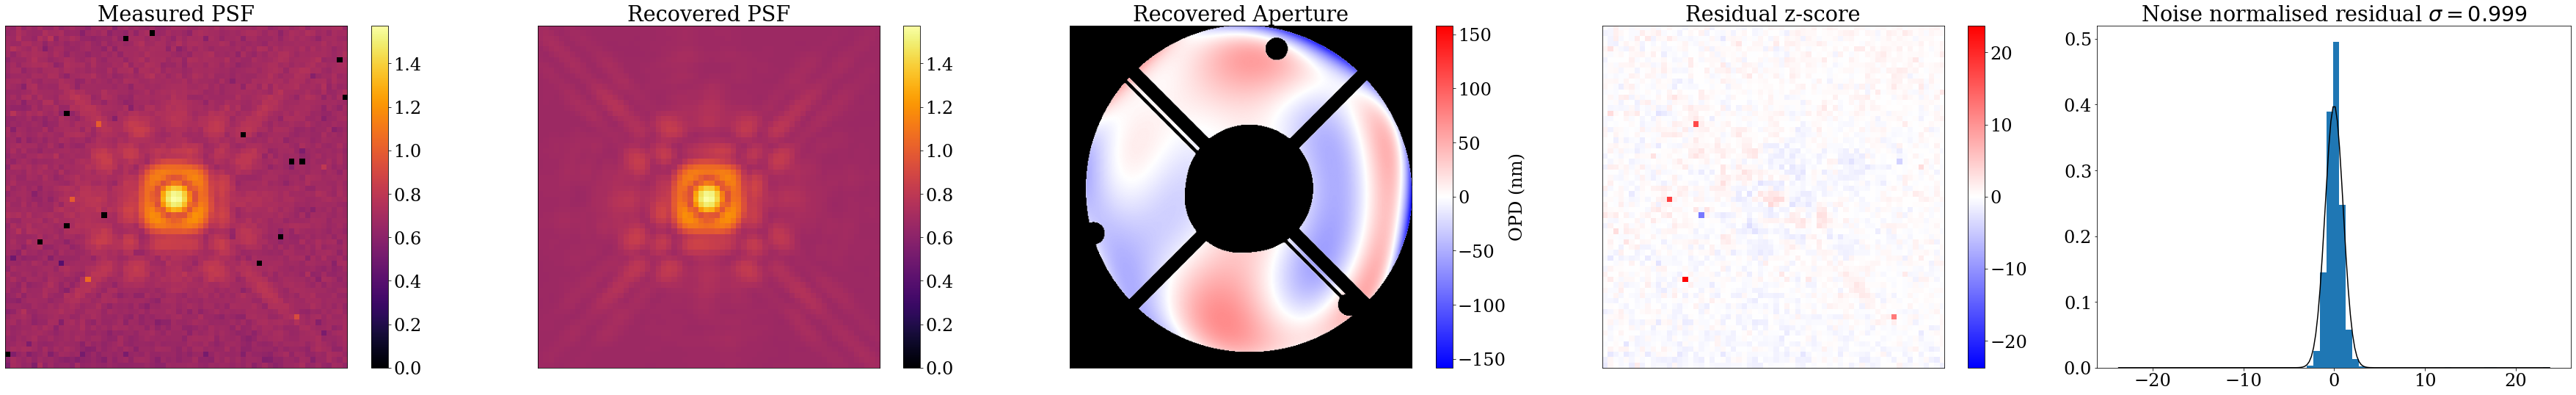

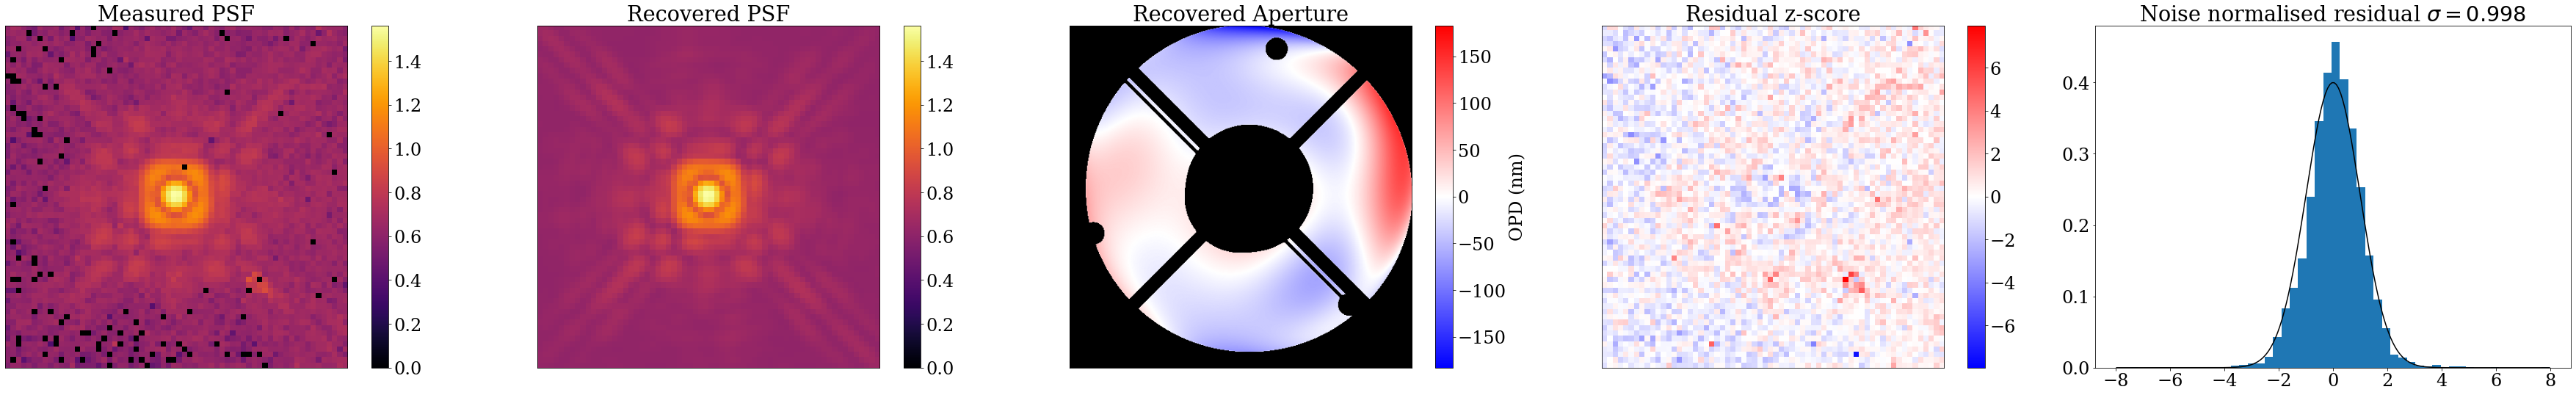

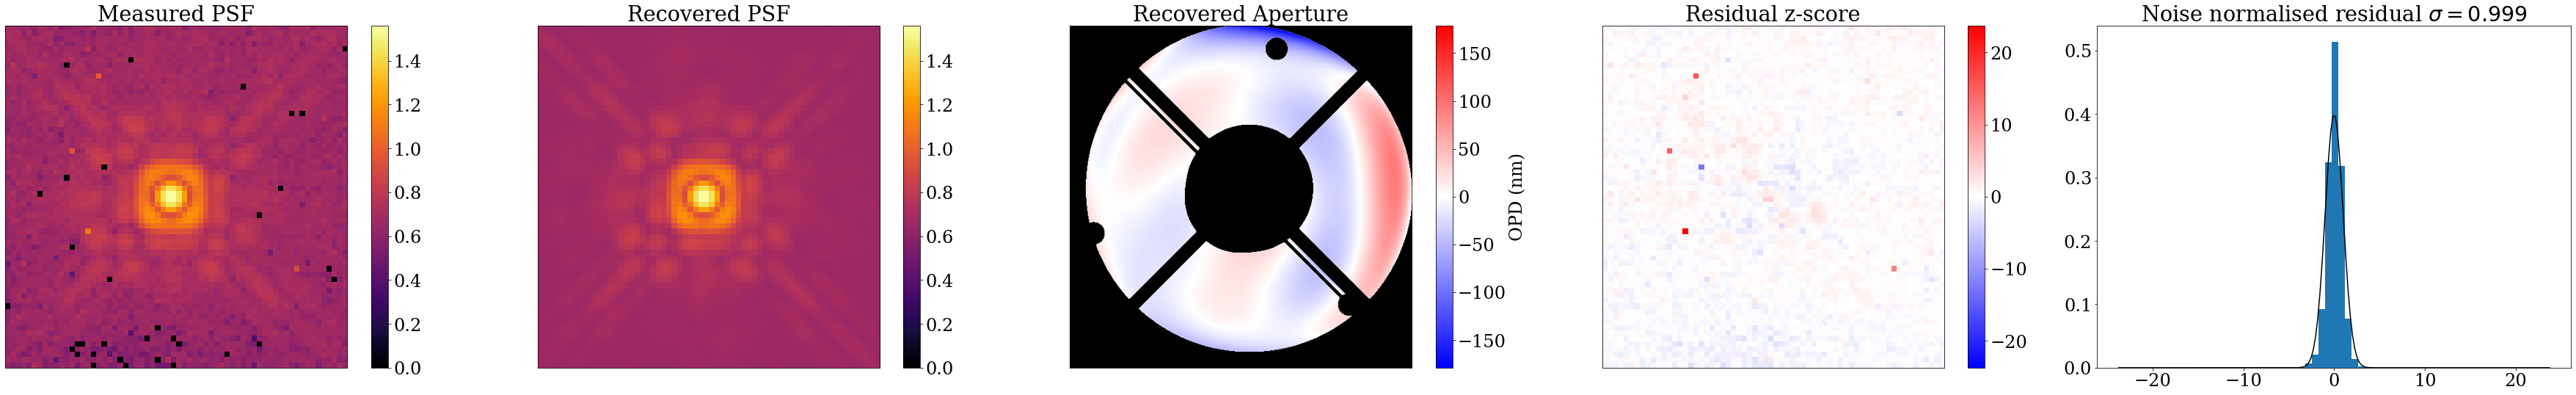

In [18]:
plot_params(params_history_relative, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=True)

In [19]:
# final_params = ModelParams(params_history[-1])
final_params = optimise_optimistix(params_history[-1], model_single, exposures_single, project=True, diag=True)

In [20]:
final_params.params

{'aberrations': {'n8ry03vbq': Array([ 26.36914284, -33.81436665, -11.6405746 ,   3.52061738,
           1.372321  , -16.75131954,  28.77909298, -23.52356454,
          -0.06385136, -10.99042539,   3.11062799,   4.16347344,
          -7.79697459,  -7.12530731,   0.67573419,  -1.00558574,
           2.05618201, -16.96012637,   0.12692682, -20.61533967,
          -5.40700373, -16.00190499, -18.77182054,   0.35853005,
          -7.01357749,  -1.45938507,  -1.22609723,  -4.08133275,
           0.09145125,   1.61710834], dtype=float64),
  'n8ry03vcq': Array([ -9.9782695 , -15.42594266, -18.1015524 ,  -2.79507576,
           9.72084859, -10.57435426,  24.50296311, -15.69178091,
          15.30960706,  -5.16570687,  -4.03547092,  -6.03774233,
         -14.99464205,   0.24787149,   8.03236449,  -6.54134731,
           3.62128774,  -9.35690056,  -3.7938719 , -11.28640235,
          -3.40641832,  11.40907324,  17.75715797,   2.75941823,
         -14.44031751, -14.11008658,  -0.15512243,  -2.73495

In [21]:
#sol.stats

0.998590243205371
0.9990946595775858
0.9980333654081012
0.9987198327150879


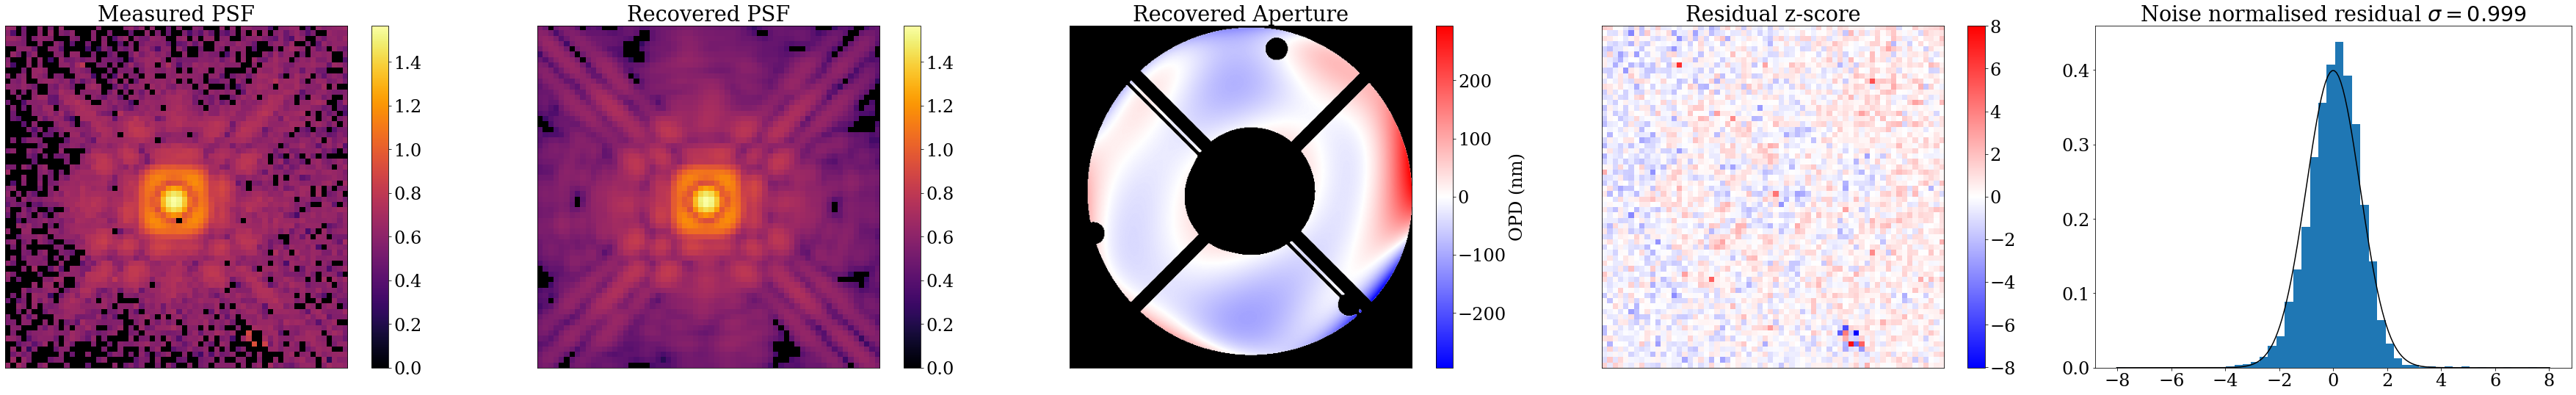

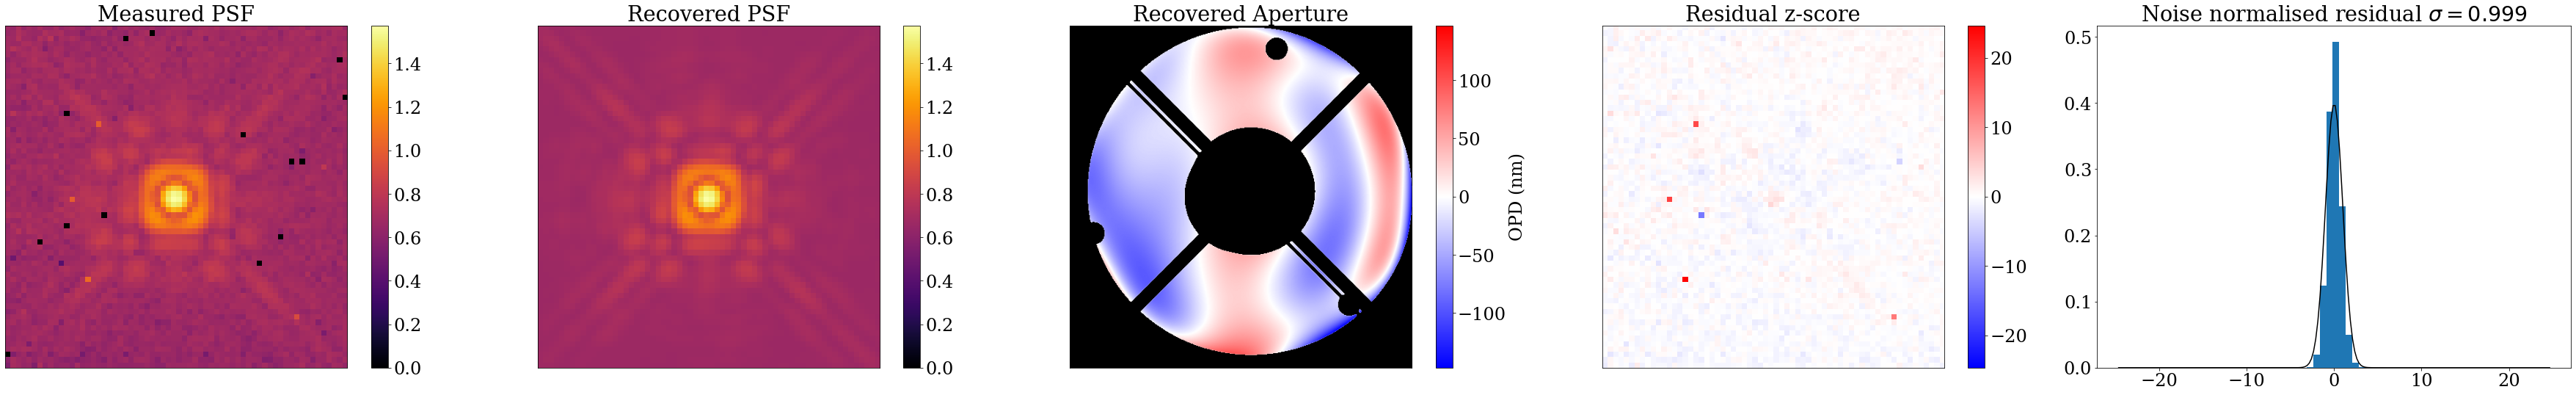

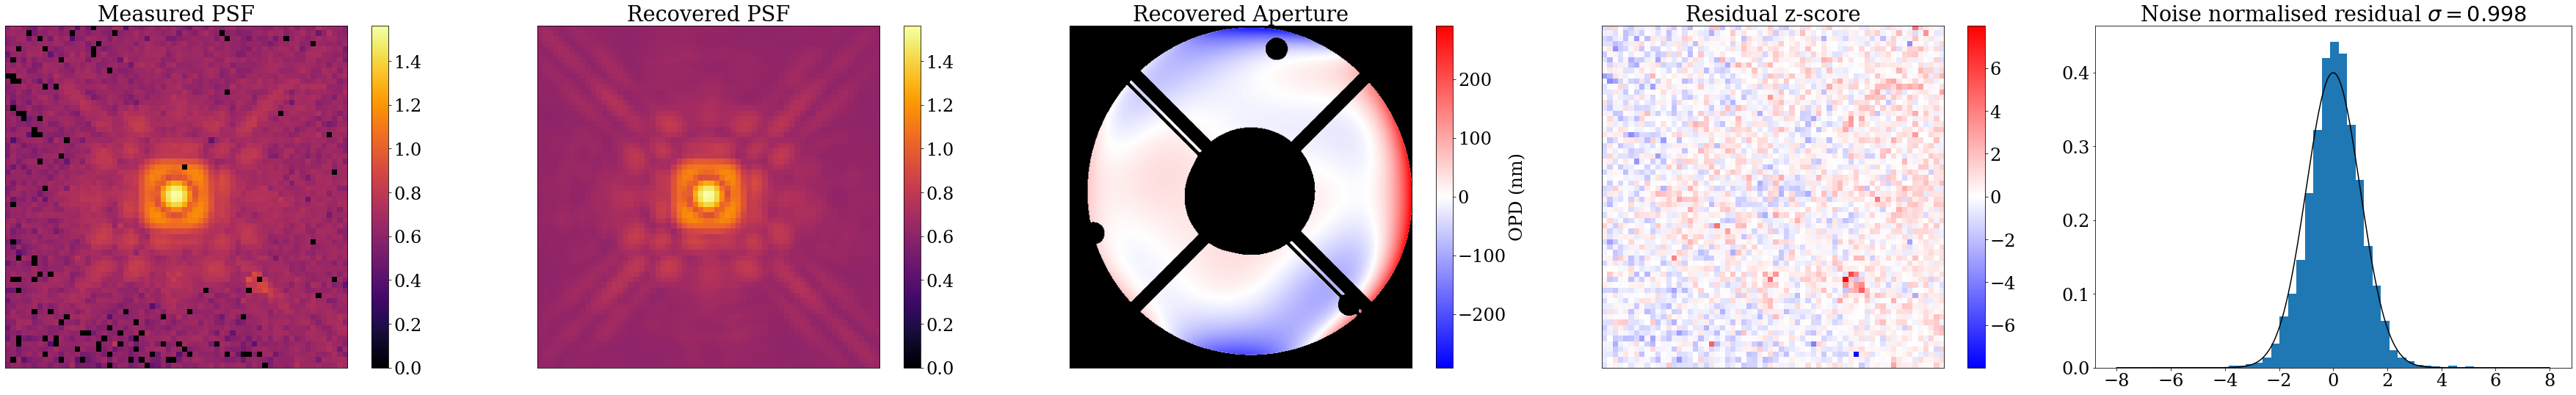

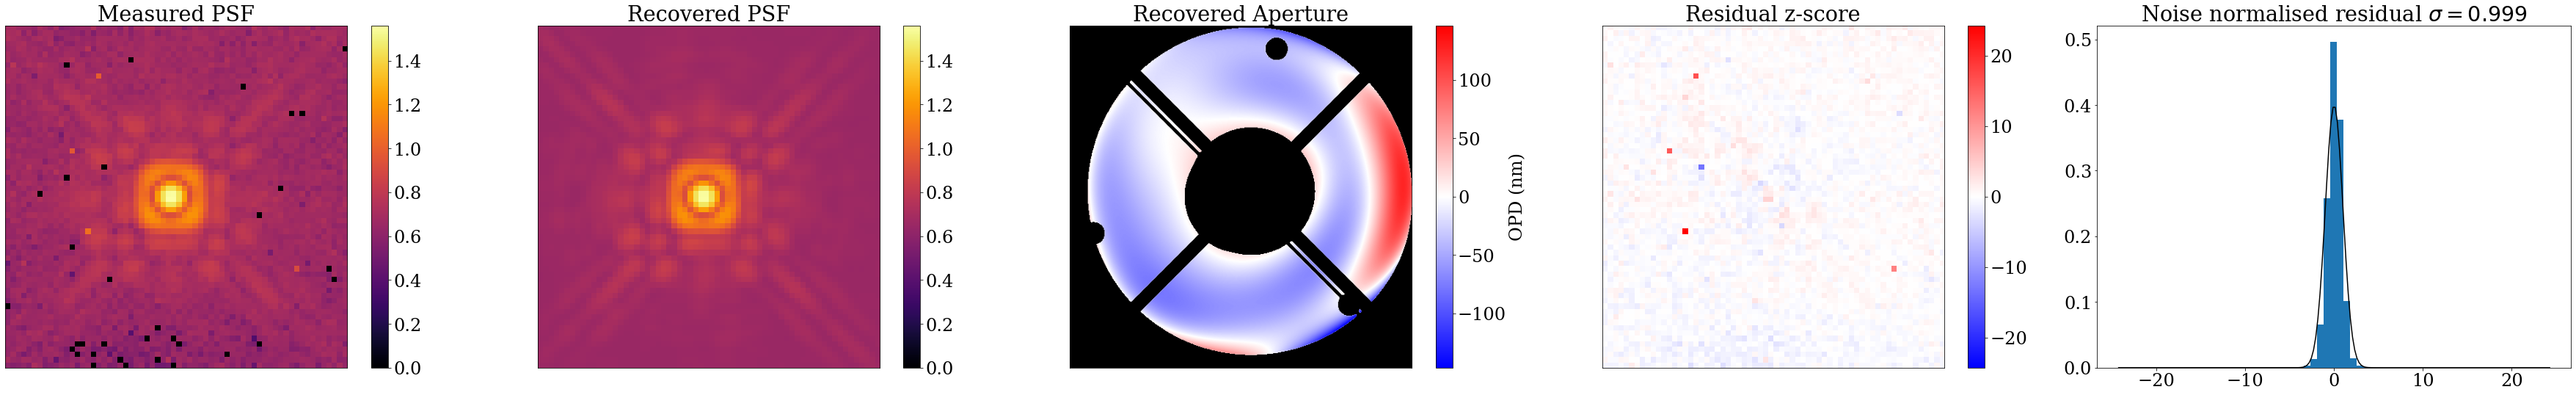

In [22]:
plot_comparison(final_params.inject((model_single)), final_params, exposures_single, quadrature=True)

In [23]:
# calculate spectrum

In [24]:
def loss_fn(params, exposures, model):
    mdl = params.inject(model)
    return np.nansum(np.asarray([posterior(mdl,exposure) for exposure in exposures]))


In [25]:
final_params.params

{'aberrations': {'n8ry03vbq': Array([ 26.36914284, -33.81436665, -11.6405746 ,   3.52061738,
           1.372321  , -16.75131954,  28.77909298, -23.52356454,
          -0.06385136, -10.99042539,   3.11062799,   4.16347344,
          -7.79697459,  -7.12530731,   0.67573419,  -1.00558574,
           2.05618201, -16.96012637,   0.12692682, -20.61533967,
          -5.40700373, -16.00190499, -18.77182054,   0.35853005,
          -7.01357749,  -1.45938507,  -1.22609723,  -4.08133275,
           0.09145125,   1.61710834], dtype=float64),
  'n8ry03vcq': Array([ -9.9782695 , -15.42594266, -18.1015524 ,  -2.79507576,
           9.72084859, -10.57435426,  24.50296311, -15.69178091,
          15.30960706,  -5.16570687,  -4.03547092,  -6.03774233,
         -14.99464205,   0.24787149,   8.03236449,  -6.54134731,
           3.62128774,  -9.35690056,  -3.7938719 , -11.28640235,
          -3.40641832,  11.40907324,  17.75715797,   2.75941823,
         -14.44031751, -14.11008658,  -0.15512243,  -2.73495

In [26]:
# F, unflatten = zdx.batching.hessian(f, {"spectrum":params_history[-1]["spectrum"]}, nbatches=2*len(exposures_single))

In [27]:
f = lambda params: loss_fn(ModelParams(final_params.params|params), exposures_single, final_params.inject((model_single)))
F, unflatten = zdx.batching.hessian(f, final_params.params, nbatches=40)

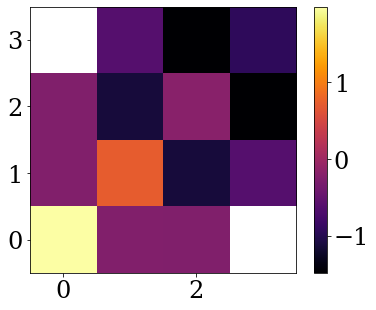

In [28]:
plt.imshow(np.log10(F[-(npoly):, -(npoly):]))
plt.colorbar()

In [29]:
np.linalg.cond(F[-(npoly):, -(npoly):])

Array(947.20750444, dtype=float64)

In [30]:
cov_f110w = np.linalg.inv(F)[-(npoly):, -(npoly):]
spectrum_err = np.diag(np.sqrt(np.abs(cov_f110w)))


In [31]:
final_params

ModelParams(
  params={
    'aberrations':
    {
      'n8ry03vbq': f64[30],
      'n8ry03vcq': f64[30],
      'n8ry04vfq': f64[30],
      'n8ry04vgq': f64[30]
    },
    'bias':
    {
      'n8ry03vbq': f64[],
      'n8ry03vcq': f64[],
      'n8ry04vfq': f64[],
      'n8ry04vgq': f64[]
    },
    'cold_mask_shift': {'global': f64[2]},
    'defocus':
    {
      'n8ry03vbq': f64[],
      'n8ry03vcq': f64[],
      'n8ry04vfq': f64[],
      'n8ry04vgq': f64[]
    },
    'positions':
    {
      'n8ry03vbq': f64[2],
      'n8ry03vcq': f64[2],
      'n8ry04vfq': f64[2],
      'n8ry04vgq': f64[2]
    },
    'quadrature':
    {
      'n8ry03vbq': f64[],
      'n8ry03vcq': f64[],
      'n8ry04vfq': f64[],
      'n8ry04vgq': f64[]
    },
    'spectrum': {'HZ4_F160W': f64[4]}
  }
)

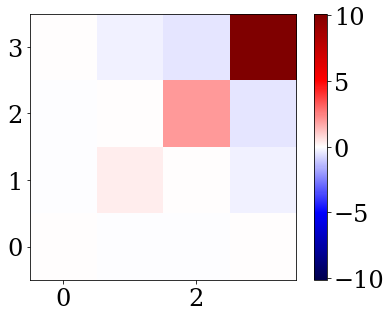

In [32]:
plt.imshow(cov_f110w, cmap='seismic', vmin=-np.max(np.abs(cov_f110w)), vmax=np.max(np.abs(cov_f110w)))
plt.colorbar()


In [33]:
cov2_f110w = np.linalg.inv(F)

In [34]:
np.sqrt(np.diag(cov_f110w))

Array([0.11441045, 0.59121537, 1.40978096, 3.18090462], dtype=float64)

In [35]:
final_params.get("spectrum.HZ4_F160W")[:]/np.sqrt(np.diag(cov2_f110w[-(npoly):, -(npoly):]))

Array([1073.21514699,  -90.32943747,  -13.2784755 ,  -13.35251494],      dtype=float64)

In [36]:
final_params.get("spectrum.HZ4_F160W")[0]/np.sqrt(np.diag(cov2_f110w[-(npoly):, -(npoly):]))

Array([1073.21514699,  207.68578403,   87.09652931,   38.60129215],      dtype=float64)

In [37]:
print("mode covariances")
print(final_params.get("spectrum.HZ4_F160W")[0]/np.sqrt(np.diag(cov_f110w)))

print(final_params.get("spectrum.HZ4_F160W")[0]*np.sqrt(np.real(np.linalg.eigvals(F[-(npoly):, -(npoly):]))))


mode covariances
[1073.21514699  207.68578403   87.09652931   38.60129215]
[1213.49343931  283.56978027   98.76074613   39.42891874]


In [38]:
c0 = final_params.get("spectrum.HZ4_F160W")[0]
np.max((np.sqrt(np.diag(cov_f110w)) * np.abs(spectrum_basis)).T/(c0*spectrum_basis[:,0]),axis=1)

Array([0.00093178, 0.00783035, 0.02712689, 0.06799414], dtype=float64)

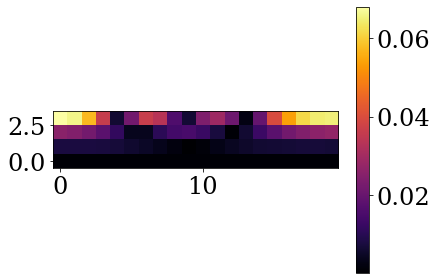

In [39]:
plt.imshow((np.sqrt(np.diag(cov_f110w)) * np.abs(spectrum_basis)).T/(c0*spectrum_basis[:,0]))
plt.colorbar()

In [40]:
# final_params.get("spectrum.U20581_F110W")[0]/np.sqrt(vals)

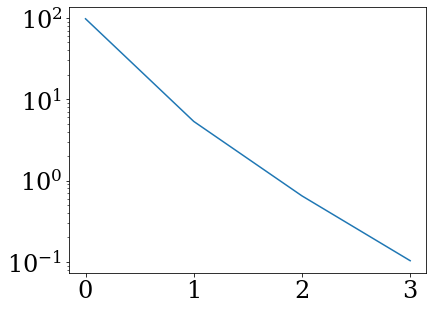

In [41]:
vals, vects = np.linalg.eig(F[-(npoly):, -(npoly):])#+fsh['n8yj02wyq.spectrum'])

order = np.argsort(vals)[::-1]

#plt.figure(figsize=(10,10))
#plt.xlabel("Coefficient")

#for i in range(5):
#    plt.plot(np.arange(npoly),np.real(vects[:,order[i]]), label=f"{i}")
#plt.legend()

plt.semilogy(np.sort(np.real(vals))[::-1])

In [42]:
wavels, bandpass = calc_throughput("F160W", nwavels=nwavels*2)

In [43]:
#final_params = ModelParams(params_history[-1])

In [44]:
fname = "2M1439.fits"
data = fits.getdata(fname, ext=0).astype(np.float32)

In [45]:
cov_f110w.shape

(4, 4)

In [46]:
keck = pd.read_csv("oned.csv")
keck_wv = keck["wavelength"].to_numpy()
keck_spec = keck["eps/thoughput"].to_numpy()

Text(0.5, 0, 'Wavelength (um)')

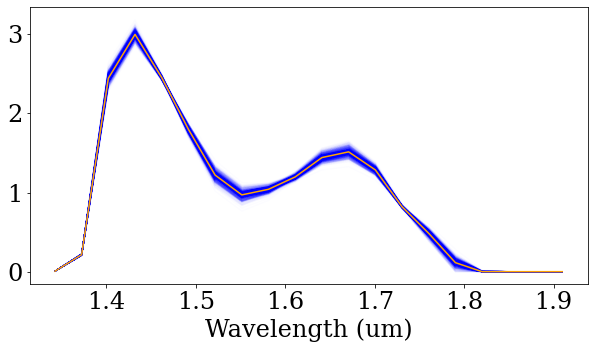

In [47]:
plt.figure(figsize=(10,5))

wv, filt = calc_throughput("F160W", nwavels=nwavels)


spec = PreCombinedBasisSpectrum(wv, final_params.get("spectrum.HZ4_F160W"), spectrum_basis)

sp = spec.spec_weights()/spec.flux/(wv*1e6)

smax = np.mean(sp)#*0.87

sp = sp/smax

plt.plot(wv*1e6, sp, color='orange')

for i in range(1000):
    coeffs = numpy.random.multivariate_normal(final_params.get("spectrum.HZ4_F160W"), (cov_f110w))
    spec = PreCombinedBasisSpectrum(wv, coeffs, spectrum_basis)
    plt.plot(wv*1e6, spec.spec_weights()/spec.flux/(wv*1e6)/smax, color='b', alpha=0.01, zorder=0)
    # try 32nd and 68th percentile plot


wv_range = (data[0]*1e-6 > np.min(wv)) & (data[0]*1e-6 < np.max(wv))
# plt.errorbar(data[0][wv_range], data[1][wv_range]/np.mean(data[1][wv_range]), data[2][wv_range]/np.mean(data[1][wv_range]))

plt.xlabel("Wavelength (um)")
# plt.axvline(0.81)
# plt.axvline(1.385)
# plt.plot(keck_wv/1e4, keck_spec/np.max(keck_spec)*2)

In [48]:
final_params.params

{'aberrations': {'n8ry03vbq': Array([ 26.36914284, -33.81436665, -11.6405746 ,   3.52061738,
           1.372321  , -16.75131954,  28.77909298, -23.52356454,
          -0.06385136, -10.99042539,   3.11062799,   4.16347344,
          -7.79697459,  -7.12530731,   0.67573419,  -1.00558574,
           2.05618201, -16.96012637,   0.12692682, -20.61533967,
          -5.40700373, -16.00190499, -18.77182054,   0.35853005,
          -7.01357749,  -1.45938507,  -1.22609723,  -4.08133275,
           0.09145125,   1.61710834], dtype=float64),
  'n8ry03vcq': Array([ -9.9782695 , -15.42594266, -18.1015524 ,  -2.79507576,
           9.72084859, -10.57435426,  24.50296311, -15.69178091,
          15.30960706,  -5.16570687,  -4.03547092,  -6.03774233,
         -14.99464205,   0.24787149,   8.03236449,  -6.54134731,
           3.62128774,  -9.35690056,  -3.7938719 , -11.28640235,
          -3.40641832,  11.40907324,  17.75715797,   2.75941823,
         -14.44031751, -14.11008658,  -0.15512243,  -2.73495